# Goal: To construct a 1-D template bank for Newtonian chirp signals.

#### References: 

- **BS Sathyaprakash and SV Dhurandhar** (*Choice of filters for the detection of gravitational waves from coalescing binaries*, 1991) (10.1103/PhysRevD.44.3819)
  
- **SV Dhurandhar and BS Sathyaprakash** (*Choice of filters for the detection of gravitational waves from coalescing binaries. II. Detection in colored noise*, 1994)(10.1103/PhysRevD.49.1707)
  
- **BJ Owen** (*Search templates for gravitational waves from inspiraling binaries: Choice of template spacing*, 1996) (10.1103/PhysRevD.53.6749)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pycbc.psd, pycbc.types, pycbc.conversions, pycbc.filter
from matplotlib.gridspec import GridSpec
from astropy.constants import G, c, M_sun
import tqdm
from IPython.display import display, Latex


/opt/homebrew/Caskroom/miniconda/base/envs/py311/lib/python3.11/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal


## Waveform mismatch as distance metric:

- Recall that the match between normalized waveforms $\hat{h}_1$ and $\hat{h}_2$ is defined as,
\begin{equation}
        \mathcal{M}(h_1|h_2) = \mathrm{max}_{\{t_{\mathrm{c}}, \phi_{\mathrm{c}}\}} \left[ \frac{(h_1|h_2)(t_{\mathrm{c}}, \phi_{\mathrm{c}})}{\sqrt{(h_1|h_1)} \sqrt{(h_2|h_2)}} \right],
\end{equation}

- Consider the following,
\begin{equation}
    \hat{h}(\lambda + \Delta \lambda) = \hat{h}(\lambda) + \Delta h \tag{2}
\end{equation}

\begin{align}
    \implies \lvert| \Delta h \rvert|^2 &= \lvert| \hat{h}(\lambda + \Delta \lambda) - \hat{h}(\lambda)  \rvert|^2 \nonumber \\
    &= \lvert| \hat{h}(\lambda + \Delta \lambda) \rvert|^2 + \lvert| \hat{h}(\lambda) \rvert|^2 - 2\mathcal{M}(\hat{h}(\lambda + \Delta \lambda), \hat{h}(\lambda)) \nonumber \\
    &= 2(1 - \mathcal{M}) \nonumber \\    
\end{align}

- Define waveform mismatch $\epsilon = 1 - \mathcal{M} ~ \implies ~ \epsilon = \frac{\lvert| \Delta h \rvert|^2}{2}$

- To the first order, the difference vector $\Delta h = \frac{\partial \hat{h}}{\partial \lambda^{\alpha}} \Delta \lambda^{\alpha} ~ \implies ~ \lvert| \Delta h \rvert|^2 = \left( \frac{\partial \hat{h}}{\partial \lambda^{\alpha}}, \frac{\partial \hat{h}}{\partial \lambda^{\beta}} \right) \Delta \lambda^{\alpha} \Delta \lambda^{\beta}.$

- Thus a mismatch metric on the signal manifold can be defined as,
\begin{align}
    ds^2 = g_{\alpha \beta} \Delta \lambda^{\alpha} \Delta \lambda^{\beta} = \frac{1}{2}\left( \frac{\partial \hat{h}}{\partial \lambda^{\alpha}}, \frac{\partial \hat{h}}{\partial \lambda^{\beta}} \right) \Delta \lambda^{\alpha} \Delta \lambda^{\beta}, \tag{3}
\end{align}
Thus norm of the difference vector is a measure of the distance between the waveforms $\hat{h}(\lambda + \Delta \lambda)$ and $\hat{h}(\lambda)$, which you may recall from the previous lectures.



In [2]:
sample_rate = 4096
duration    = 32
f_lower     = 20
f_high      = 1024
delta_t     = 1.0 / sample_rate
delta_f     = 1.0 / duration
flen        = int(sample_rate * duration / 2) + 1
inj_time    = 30

zdhp_psd = pycbc.psd.analytical.aLIGOZeroDetHighPower(
               flen, delta_f, f_lower)



## The Newtonian chirp signal:

- Consider the frequency domain GW signal of the following form,
\begin{equation}
    h(f; \lambda) = A(f; \lambda) ~ \mathrm{e}^{i\Phi (f; \lambda)} \tag{4}
\end{equation}

Here,

\begin{align}
    A(f; \lambda) &= A(\lambda) ~ f^{-7/6} \tag{5} \\
    \Phi(f; \lambda) &= -\frac{\pi}{4} - \phi_c + \phi(f; \lambda)\nonumber \\
    &=-\frac{\pi}{4} - \phi_c + 2\pi ft_c + \psi(f; \lambda_{\mathrm{int}}) \tag{6}
\end{align}

- For a Newtonian Chirp signal,

\begin{align}
    \psi(f; \lambda_{\mathrm{int}}) = \psi_{\mathrm{N}}(f; M_{\mathrm{tot}}, \eta) = \frac{3}{128 \eta} (\pi M_{\mathrm{tot}} f)^{-5/3} \tag{7}
\end{align}

where $M_{\mathrm{tot}} = m_1 + m_2$ is the total mass and $\eta = \frac{\mu}{M_{\mathrm{tot}}}$ the symmetric mass ratio, defined as the ratio of reduced mass to the total mass of the binary.

- Simplifying the parameter dependence;

\begin{equation}
    \psi_{\mathrm{N}}(f; M_{\mathrm{tot}}, \eta) = \psi_{\mathrm{N}}(f; \tau_0) = \frac{6 \pi f_{\mathrm{low}}}{5} \left( \frac{f}{f_{\mathrm{low}}} \right)^{-5/3} \tau_0 \tag{8}
\end{equation}
where,

\begin{equation}
    \tau_{0} = \frac{5}{256\pi\eta f_{\mathrm{low}}}\left( \pi M_{\mathrm{low}} f_{\mathrm{low}} \right)^{-5/3} \tag{9}
\end{equation}



In [3]:
freq_arr = zdhp_psd.sample_frequencies
band_mask = (freq_arr >= f_lower) & (freq_arr <= f_high)
freqs = freq_arr[band_mask]
psd = zdhp_psd[band_mask]

In [4]:
def get_two_pn_chirp(m1, m2, tc, phi_c, amp, newtonian_chirp=True):
    m_total, eta = (m1 + m2)*(M_sun.value * G.value / c.value**3), pycbc.conversions.eta_from_mass1_mass2(m1, m2)
    v = (np.pi * m_total * freqs)**(1/3)

    a0 = 1
    a1 = 0
    a2 = (20 / 9) * (743 / 336 + (11 / 4)*eta)
    a3 = -16 * np.pi
    a4 = 10 * ((3058673 / 1016064) + (5429 * eta / 1008) + (617 * eta**2 / 144))
    a_list = [a0, a1, a2, a3, a4]

    terms, idx = 0, 0

    if newtonian_chirp: # Set all PN coefficients to zero except the Newtonian term
        a_list[1:] = [0] * (len(a_list) - 1)
    else:
        pass

    for a in a_list:
        idx = idx + 1
        terms = terms + a * v**idx

    psi = (3 / (128 * eta * v**5)) * terms

    phi_twoPN = (2 * np.pi * freqs * tc) - phi_c - np.pi/4 + psi
    amplitude = amp * freqs**(-7.0/6.0)

    waveform = amplitude * np.exp(-1j * phi_twoPN)

    waveform_pycbc = pycbc.types.FrequencySeries(waveform,  delta_f=delta_f)
    phase_pycbc    = pycbc.types.FrequencySeries(psi, delta_f=delta_f)
    amp_pycbc      = pycbc.types.FrequencySeries(amplitude, delta_f=delta_f)
    
    return waveform_pycbc, phase_pycbc, amp_pycbc


def compute_I_of_a(a_of_f):

    weight = freqs**(-7 / 3) / psd

    num = np.trapezoid(weight * a_of_f, freqs)
    denom = np.trapezoid(weight, freqs)

    I = np.abs(num) / denom 
    return I


def get_tc_t0_matrix(phi_tc, phi_t0):
    j_tc    = compute_I_of_a(phi_tc)
    j_t0    = compute_I_of_a(phi_t0)
    j_tc_tc = compute_I_of_a(phi_tc**2)
    j_t0_t0 = compute_I_of_a(phi_t0**2)
    j_tc_t0 = compute_I_of_a(phi_tc * phi_t0)

    g_tc_tc = 0.5 * (j_tc_tc - j_tc**2)
    g_t0_t0 = 0.5 * (j_t0_t0 - j_t0**2)
    g_tc_t0 = 0.5 * (j_tc_t0 - j_tc * j_t0)

    return g_tc_tc, g_t0_t0, g_tc_t0


In [5]:
m1, m2  = 20, 20
tc      = inj_time   
phi_c   = 0.0       
amp     = 100#1e-21      

h_tilde, psi, A = get_two_pn_chirp(m1, m2, tc, phi_c, amp)
h_t    = h_tilde.to_timeseries(delta_t=delta_t)


/var/folders/z2/2wcrxzpn0nq9bm85q8_t1bfm0000gn/T/ipykernel_57413/977941358.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


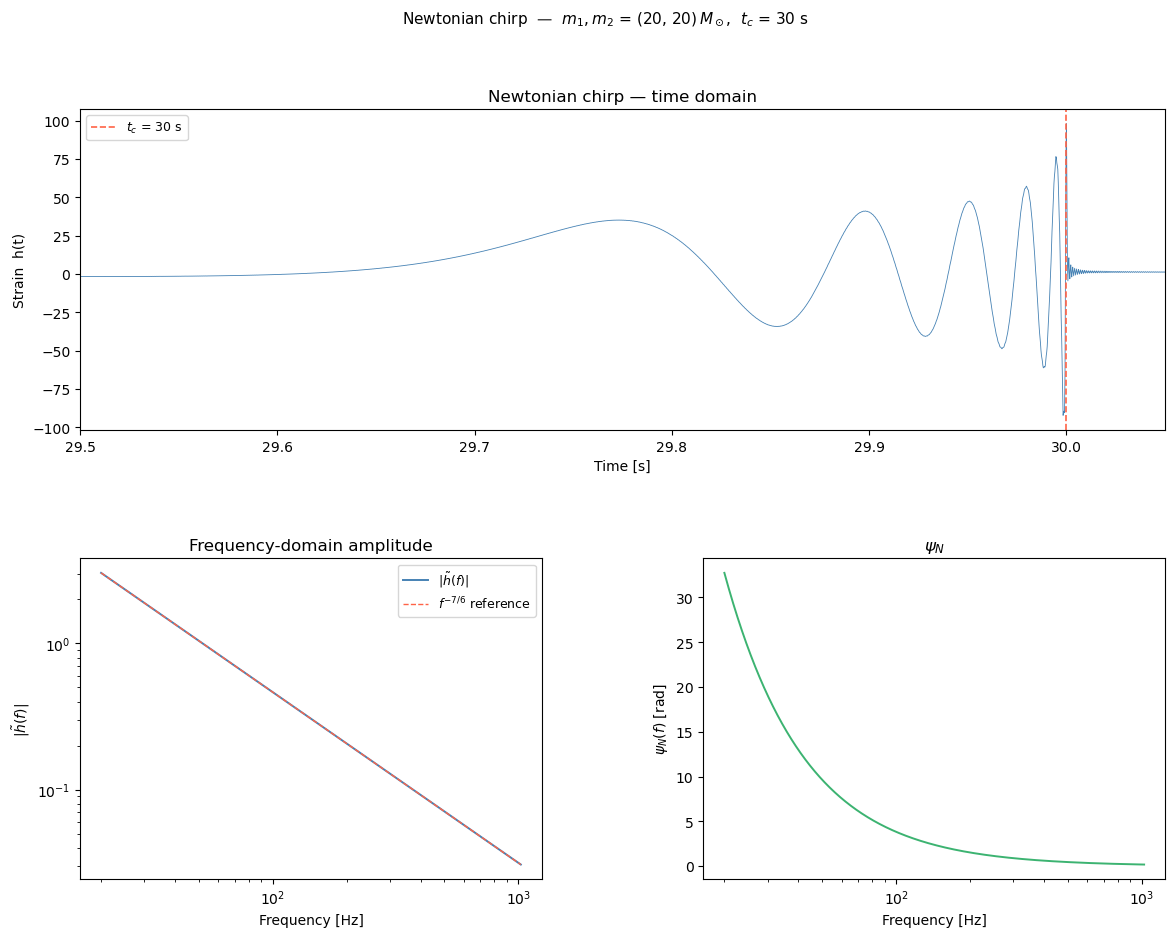

In [6]:
fig = plt.figure(figsize=(14, 10))
gs  = GridSpec(2, 2, figure=fig, hspace=0.40, wspace=0.35)


ax1 = fig.add_subplot(gs[0, :])
h_t_np = h_t.numpy()
t   = np.arange(len(h_t_np)) * delta_t
ax1.plot(t, np.real(h_t_np), lw=0.6, color='steelblue')
ax1.axvline(tc, color='tomato', lw=1.2, ls='--',
            label=r'$t_c$' + f' = {tc} s')
ax1.set_xlabel('Time [s]'); ax1.set_ylabel('Strain  h(t)')
ax1.set_title('Newtonian chirp — time domain')
ax1.set_xlim(tc - 0.5, tc + 0.05)
ax1.legend(fontsize=9)


ax2 = fig.add_subplot(gs[1, 0])
ax2.loglog(freqs, np.abs(h_tilde.numpy()),
           lw=1.4, color='steelblue', label=r'$|\tilde{h}(f)|$')
f_ref = np.logspace(np.log10(f_lower), np.log10(freqs.max()), 200)
ax2.loglog(f_ref, amp * f_ref**(-7/6), lw=1.0, ls='--', color='tomato',
           label=r'$f^{-7/6}$ reference')
ax2.set_xlabel('Frequency [Hz]'); ax2.set_ylabel(r'$|\tilde{h}(f)|$')
ax2.set_title('Frequency-domain amplitude'); ax2.legend(fontsize=9)


ax3 = fig.add_subplot(gs[1, 1])
ax3.semilogx(freqs, psi.numpy(), lw=1.4, color='mediumseagreen')
ax3.set_xlabel('Frequency [Hz]'); ax3.set_ylabel(r'$\psi_N(f)$ [rad]')
ax3.set_title('$\psi_N$')

plt.suptitle(
    f'Newtonian chirp  —  '
     r'$m_1, m_2$' + f' = {m1, m2}' +
    r'$\,M_\odot$,  $t_c$ = ' + f'{tc} s', fontsize=11)
plt.tight_layout()
plt.show()

### The recipe to compute $g_{ij}$:
For match computation, we need normalized waveforms, and the norm of waveform is computed as,

\begin{align}
    |h(\lambda)|^2 &= \int_{f_{\mathrm{low}}}^{f_{\mathrm{high}}} \frac{h^*(f, \lambda) ~ h(f;\lambda)}{S_h(f)} ~ df \nonumber \\ 
    &= A^2(\lambda) \int_{f_{\mathrm{low}}}^{f_{\mathrm{high}}} \frac{f^{-7/3}}{S_h(f)} ~ df \nonumber \\
    &\equiv A^2(\lambda) ~ \mathcal{N} \tag{10}
\end{align}

Thus, the normalized waveform is given by;

\begin{equation}
    \hat{h}(f; \lambda) = \frac{h(f; \lambda)}{|h(f; \lambda)|} = \frac{f^{-7/6} ~ e^{i\Phi(f; \lambda)}}{\sqrt{\mathcal{N}}} \tag{11}
\end{equation}

Now, the Inner-product (maximized over $\phi_0$) between a normalized signal $\hat{h}(f; \lambda)$ and a perturbed one $\hat{h}(f; \lambda + \Delta \lambda)$ is given by,


\begin{align}
\mathcal{M}(\lambda,\Delta\lambda)
=
\bigl(\,\hat h(f;\lambda)\mid \hat h(f;\lambda+\Delta\lambda)\,\bigr) \tag{12}
&=
\frac{ 
  \displaystyle
  \left\lvert
    \int_{f_{\mathrm{low}}}^{f_{\mathrm{high}}}
      \frac{h^{*}(f,\lambda)\,h(f;\lambda+\Delta\lambda)}{S_{h}(f)} \, df
  \right\rvert
}{A(\lambda) ~ A(\lambda + \Delta \lambda) ~ \mathcal{N}} \nonumber \\
&= \frac{ 
  \displaystyle
  \left\lvert
    \int_{f_{\mathrm{low}}}^{f_{\mathrm{high}}}
      \frac{f^{-7/3} ~ e^{i \left[ \phi(f; \lambda + \Delta \lambda) - \phi(f; \lambda) \right]}}{S_{h}(f)} \, df
  \right\rvert
}{\mathcal{N}} \tag{13}
\end{align}

Now, the exponential $e^{i \Delta \phi}$, where $\Delta \phi \equiv \phi(\lambda + \Delta \lambda) - \phi(\lambda)$ can be approximated upto $\mathcal{O}(\Delta \phi^2)$, thus;

\begin{equation}
    \mathcal{M}(\lambda,\Delta\lambda) \approx 
  \displaystyle
  \left\lvert
    \int_{f_{\mathrm{low}}}^{f_{\mathrm{high}}}
      \frac{f^{-7/3} ~ \left[ 1 + i\Delta \phi - \frac{\Delta \phi^2}{2} \right]}{S_{h}(f)} \, df
  \right\rvert \times \frac{1}{\mathcal{N}} \tag{14}
\end{equation}

Now, define a functional $\mathcal{J}[a]$, as follows;

\begin{equation}
    \mathcal{J}[a] = \frac{1}{\mathcal{N}} \times \int_{f_{\mathrm{low}}}^{f_\mathrm{high}} \frac{f^{-7/3}}{S_h (f)} a(f) ~ df \tag{15}
\end{equation}

Now, upto first order, $\Delta \phi \approx \frac{\partial \phi}{\partial \lambda^{\alpha}} \Delta \lambda^{\alpha} \equiv \phi_{\alpha} \Delta \lambda^{\alpha} ~ \implies ~ (\Delta \phi)^2 \approx \phi_{\alpha} \phi_{\beta} \Delta \lambda^{\alpha} \Delta \lambda^{\beta}$


Therefore,

\begin{align}
    \mathcal{M}(\lambda,\Delta\lambda) &\approx 
  \displaystyle
  \left\lvert
    \int_{f_{\mathrm{low}}}^{f_{\mathrm{high}}}
      \frac{f^{-7/3} ~ \left[ 1 + i\phi_{\alpha}\Delta \lambda^{\alpha} - \frac{\phi_{\alpha} \phi_{\beta}}{2} \Delta \lambda^{\alpha} \Delta \lambda^{\beta} \right]}{S_{h}(f)} \, df
  \right\rvert \times \frac{1}{\mathcal{N}} \nonumber \\
  &= \left \lvert \mathcal{NJ}[1] + i \mathcal{NJ}[\phi_{\alpha}] \Delta \lambda^{\alpha} - \frac{\mathcal{NJ}[\phi_{\alpha} \phi_{\beta}]}{2} \Delta \lambda^{\alpha} \Delta \lambda^{\beta} \right \rvert \times \frac{1}{\mathcal{N}} \nonumber \\
  &= \left[ \left( \mathcal{J}(1) -  \frac{\mathcal{J}[\phi_{\alpha} \phi_{\beta}]}{2} \Delta \lambda^{\alpha} \Delta \lambda^{\beta}\right)^2 + \mathcal{J}[\phi_\alpha] \mathcal{J}[\phi_\beta] \Delta \lambda^{\alpha} \Delta \lambda^{\beta} \right]^{1/2} \nonumber \nonumber \\
  &\approx \mathcal{J}[1] - \frac{1}{2} \left( \mathcal{J}[\phi_{\alpha} \phi_{\beta}] - \mathcal{J}[\phi_{\alpha}] \mathcal{J}[\phi_{\beta}]\right) \Delta \lambda^{\alpha} \Delta \lambda^{\beta}\nonumber \\
\end{align}

Thus, 
\begin{equation}
    \mathcal{M}(\lambda,\Delta\lambda) = 1 - g_{\alpha \beta} \Delta \lambda^{\alpha} \Delta \lambda^{\beta} \tag{16}
\end{equation}

where,

\begin{equation}
    g_{\alpha \beta} = \frac{1}{2} \left( \mathcal{J}[\phi_{\alpha} \phi_{\beta}] - \mathcal{J}[\phi_{\alpha}] \mathcal{J}[\phi_{\beta}] \right) \tag{17}
\end{equation}

In [7]:
phi_tc = 2 * np.pi * freqs
phi_t0 = ((6 * np.pi * f_lower) / 5) * (freqs / f_lower)**(-5/3)

y_tc_tc, y_t0_t0, y_tc_t0 = get_tc_t0_matrix(phi_tc, phi_t0)

display(Latex(rf"$\gamma_{{tc,tc}} = {y_tc_tc:.2e}$"))
display(Latex(rf"$\gamma_{{t0,t0}} = {y_t0_t0:.2e}$"))
display(Latex(rf"$\gamma_{{tc,t0}} = {y_tc_t0:.2e}$"))


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

#### Projecting out the time component.

$$
g_{ij} = \gamma_{ij} - \frac {\gamma_{0i} \gamma_{0j}}{\gamma_{00}}
$$

In [8]:
g_t0_t0 = y_t0_t0 - (y_tc_t0**2 / y_tc_tc)
display(Latex(rf"$g_{{t0,t0}} = {g_t0_t0:.2e}$"))

<IPython.core.display.Latex object>

### Expected no. of templates:

- Expected number of template banks can be computed as the ratio of total proper coordinate volume, divided by the volume occupied by single template cell.

\begin{equation}
        N = \frac{\int d^n \lambda \sqrt{\| g \|}}{ds^n} \tag{18}
\end{equation}

In [9]:

#? Define a resonable range for chirp masses.
m_chirp_min, m_chirp_max = 5, 30

#? Compute the corresponding tau0 range.
tau0_min, tau0_max = pycbc.conversions.tau0_from_mchirp(m_chirp_max, f_lower), pycbc.conversions.tau0_from_mchirp(m_chirp_min, f_lower)
display(Latex(rf"$\tau_0$ range: {tau0_min:.2f} s to {tau0_max:.2f} s"))

#? Mismatch Criteria
eps_max = 0.03

coord_vol = g_t0_t0**0.5 * (tau0_max - tau0_min)
single_cell_volume = 2 * np.sqrt(eps_max)


N_temp = int(coord_vol / single_cell_volume)

display(Latex(f"Coordinate volume: {coord_vol:.2f}"))
display(Latex(f"Single template volume: {single_cell_volume:.2f}"))
display(Latex(f"Expected no. of templates: {N_temp}"))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

#### (Q1) What would be the volume occupied by single template cell in a 2-D paramters space? What about N-D?

- Ans:

#### (Q2) Estimate the size of the $t_c-\tau_0$ template bank. 

- Ans:

### Compute the actual template spacing based on the metric.

\begin{equation}
    ds^2 = (2 \sqrt{\epsilon_{\mathrm{max}}})^2 = g_{\tau_0 \tau_0} (\Delta \tau_0)^2 ~ \implies ~ \Delta \tau_0 = \sqrt{ \frac{4 \epsilon_{\mathrm{max}}}{g_{\tau_0 \tau_0}} } \tag{19}
\end{equation}
where $\epsilon_{\mathrm{max}} = 0.03$ is the maximum distance allowed between the unknown signal and the nearest template from the bank.

In [10]:
del_t0 = np.sqrt(4 * eps_max / g_t0_t0)

display(Latex(fr"$g = {g_t0_t0:.2e}$"))
display(Latex(fr"$\Delta \tau_0 = {del_t0:.2e} $ s"))


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [11]:

#? Construct the tau0 bank.

geom_bank = {"tau0": [], "m_chirp": []}

geom_bank_param = tau0_min
while geom_bank_param <= tau0_max:
    geom_bank["tau0"].append(geom_bank_param)
    m_chirp = pycbc.conversions.mchirp_from_tau0(geom_bank_param, f_lower)
    geom_bank["m_chirp"].append(m_chirp)
    geom_bank_param += del_t0

print(f"Constructed Bank size: {len(geom_bank['tau0'])}")

Constructed Bank size: 369


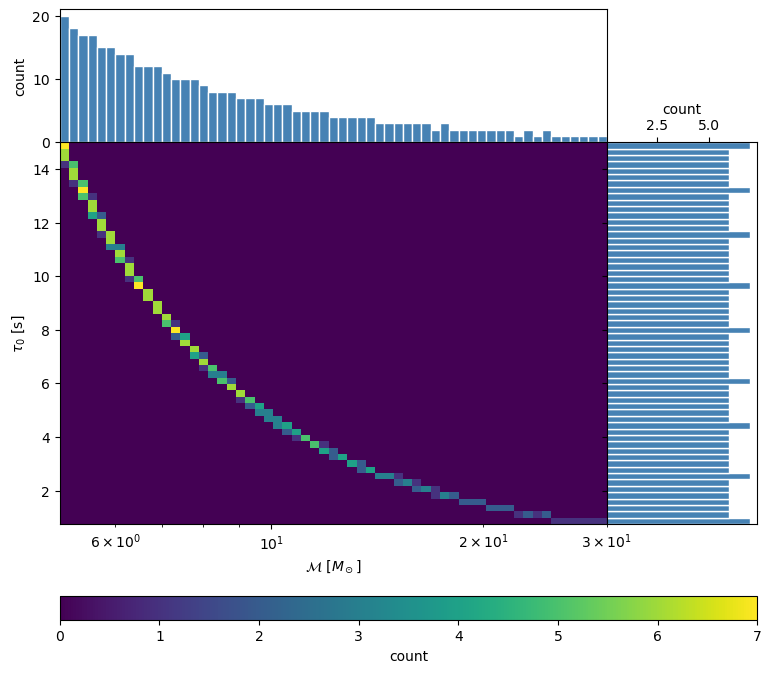

In [12]:

_tau0 = np.array(geom_bank["tau0"])
_mchirp = np.array(geom_bank["m_chirp"])

m_min = _mchirp[_mchirp > 0].min()
m_max = _mchirp.max()

bins_tau0 = 60
bins_mchirp = np.logspace(np.log10(m_min), np.log10(m_max), 60)

fig = plt.figure(figsize=(9, 8))
gs = fig.add_gridspec(2, 2, width_ratios=[4, 1.1], height_ratios=[1.1, 4],
                      wspace=0.0, hspace=0.0)

ax_top = fig.add_subplot(gs[0, 0])
ax_main = fig.add_subplot(gs[1, 0], sharex=ax_top)
ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)

h = ax_main.hist2d(_mchirp, _tau0, bins=[bins_mchirp, bins_tau0], cmap="viridis")
ax_main.set_xscale("log")
ax_main.set_xlabel(r"$\mathcal{M}$ [$M_\odot$]")
ax_main.set_ylabel(r"$\tau_0$ [s]")

ax_top.hist(_mchirp, bins=bins_mchirp, color="steelblue", edgecolor="white")
ax_top.set_xscale("log")
ax_top.set_ylabel("count")
ax_top.tick_params(axis="x", labelbottom=False)

ax_right.hist(_tau0, bins=bins_tau0, orientation="horizontal",
              color="steelblue", edgecolor="white")
ax_right.set_xlabel("count")
ax_right.tick_params(axis="y", labelleft=False)
ax_right.xaxis.set_label_position("top")
ax_right.xaxis.tick_top()
ax_right.tick_params(axis="x", labelbottom=False, labeltop=True)
ax_right.set_xlim(left=0.1)

cbar = fig.colorbar(h[3], ax=[ax_main, ax_right], orientation="horizontal",
                    pad=0.15, fraction=0.06, aspect=30)
cbar.set_label("count")

plt.show()


#### Q1) Change the chirp-mass range from both ends and compare the size of template bank. e.g, [4, 30], [5, 30] and [5, 31].

- Ans:

#### Q2) Generate a random signal of you choice from chirp-mass within the template bank parameter space range. Check the effectualness of the Newtonian bank by matched-filtering if with the template bank signals.   

- Ans: 


#### A toy example of Stochastic Bank

In [14]:
stoc_bank = {"tau0": [], "m_chirp": []}
initial_proposal = 5
stoc_bank["tau0"].append(initial_proposal)
m_chirp = pycbc.conversions.mchirp_from_tau0(initial_proposal, f_lower)
stoc_bank["m_chirp"].append(m_chirp)

consecutive_rejections = 0

while True:
    proposal = np.random.uniform(low=tau0_min, high=tau0_max)

    # Accept only if far enough from ALL existing points
    if all(np.abs(proposal - point) >= 0.5*del_t0 for point in stoc_bank["tau0"]):
        stoc_bank["tau0"].append(proposal)
        m_chirp = pycbc.conversions.mchirp_from_tau0(proposal, f_lower)
        stoc_bank["m_chirp"].append(m_chirp)
        consecutive_rejections = 0
        # print(f"Accepted. Bank size: {len(stoc_bank)}", flush=True)
    else:
        consecutive_rejections += 1
        print(f"Rejected. Consecutive rejections: {consecutive_rejections}", end='\r', flush=True)

    if consecutive_rejections >= 10000:
        print(f"Stopping. Final bank size: {len(stoc_bank['tau0'])}")
        break

Stopping. Final bank size: 546ns: 10000
